In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

mtcnn = MTCNN(
    image_size=224,
    keep_all=False,
    device=device
)

Using device: cpu


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

model.load_state_dict(torch.load("models/image/image_model_mtcnn.pth", map_location=device))
model = model.to(device)
model.eval()

print("✅ Model loaded")

✅ Model loaded


In [5]:
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")

    # Face detection
    face = mtcnn(img)

    if face is None:
        print("⚠️ No face detected, using full image")
        img_tensor = transform(img)
    else:
        # Normalize face (VERY IMPORTANT)
        img_tensor = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )(face)

    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    classes = ["Fake", "real"]
    return classes[pred.item()], confidence.item()

Prediction: real
Confidence: 0.9996


(-0.5, 255.5, 255.5, -0.5)

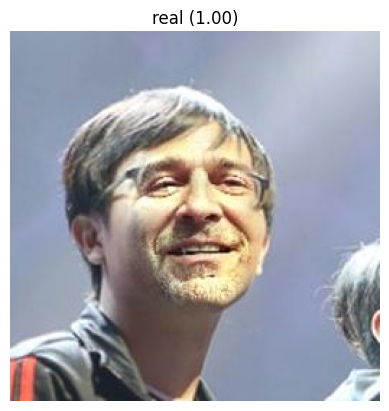

In [6]:
img_path = r"dataset/image/fake/fake_6354.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence:.4f}")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis("off")

Prediction: real
Confidence: 1.0000


(-0.5, 1439.5, 1799.5, -0.5)

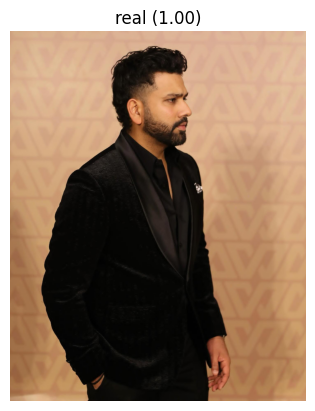

In [7]:
img_path = r"testing/rohit.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence:.4f}")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis("off")

Prediction: real
Confidence: 0.9978


(-0.5, 742.5, 1104.5, -0.5)

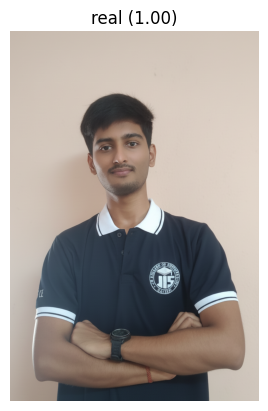

In [8]:
img_path = r"testing/pic.png"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence:.4f}")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis("off")

Prediction: real
Confidence: 0.9982


(-0.5, 255.5, 255.5, -0.5)

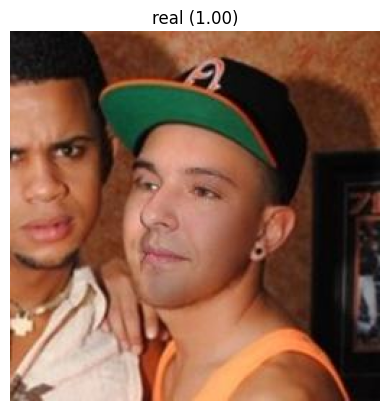

In [9]:
img_path = r"dataset/image/fake/fake_6360.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence:.4f}")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis("off")

Prediction: Fake
Confidence: 1.0000


(-0.5, 255.5, 255.5, -0.5)

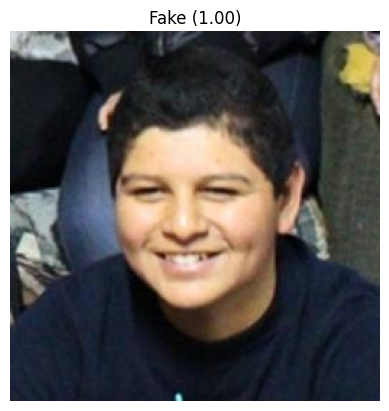

In [10]:
img_path = r"dataset/image/real/real_55.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence:.4f}")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence:.2f})")
plt.axis("off")

Prediction: Fake
Confidence: 100.00%


(-0.5, 255.5, 255.5, -0.5)

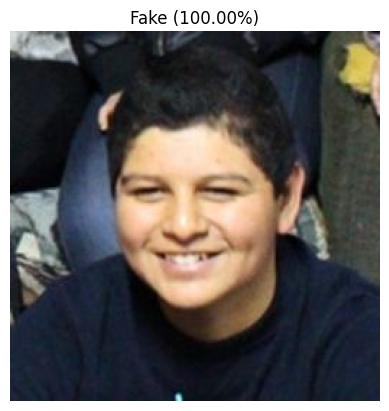

In [11]:
img_path = r"dataset/image/real/real_55.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence * 100:.2f}%")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence * 100:.2f}%)")
plt.axis("off")

Prediction: real
Confidence: 100.00%


(-0.5, 1089.5, 1404.5, -0.5)

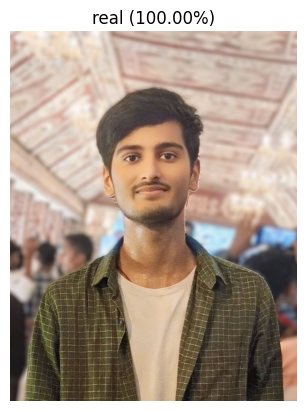

In [12]:
img_path = r"testing/mano.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence * 100:.2f}%")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence * 100:.2f}%)")
plt.axis("off")

Prediction: real
Confidence: 100.00%


(-0.5, 1843.5, 2634.5, -0.5)

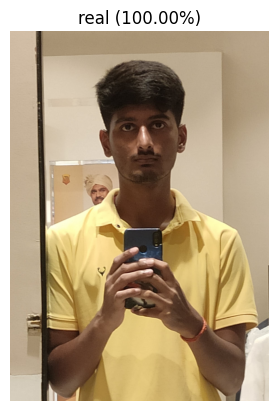

In [13]:
img_path = r"testing/pic1co.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence * 100:.2f}%")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence * 100:.2f}%)")
plt.axis("off")

Prediction: Fake
Confidence: 70.85%


(-0.5, 5878.5, 3939.5, -0.5)

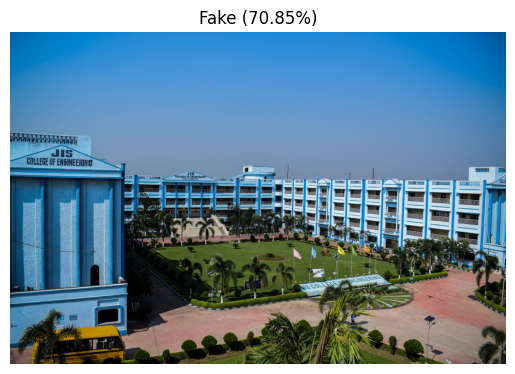

In [14]:
img_path = r"testing/JISCE.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence * 100:.2f}%")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence * 100:.2f}%)")
plt.axis("off")

Prediction: real
Confidence: 100.00%


(-0.5, 255.5, 255.5, -0.5)

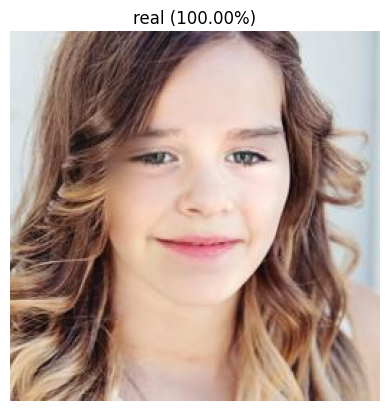

In [15]:
img_path = r"dataset/image/fake/fake_6504.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence * 100:.2f}%")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence * 100:.2f}%)")
plt.axis("off")

Prediction: real
Confidence: 100.00%


(-0.5, 255.5, 255.5, -0.5)

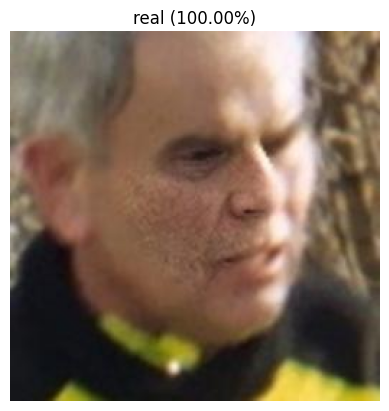

In [16]:
img_path = r"dataset/image/fake/fake_6506.jpg"  

label, confidence = predict_image(img_path)

print(f"Prediction: {label}")
print(f"Confidence: {confidence * 100:.2f}%")

# Show image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"{label} ({confidence * 100:.2f}%)")
plt.axis("off")